# Kernels and Gaussian Processes

![lecunnfun.png](images/lecunnfun.png)




In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.linalg import cho_factor, cho_solve

rng = np.random.default_rng(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

---
## 1. Data Generation

We work with a 1-D regression problem. The **true** underlying function is

$$f(x) = \sin(2\pi x), \qquad x \in [0, 1],$$

and we observe $N$ noisy realisations

$$y_n = f(x_n) + \varepsilon_n, \qquad \varepsilon_n \sim \mathcal{N}(0, \sigma_{\text{obs}}^2).$$

The dataset is $\mathcal{D} = \{(x_n, y_n)\}_{n=1}^{N}$.

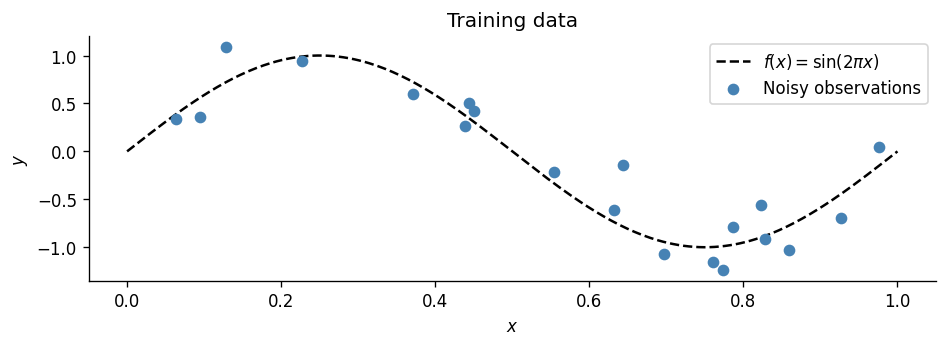

In [22]:
def true_function(x):
    return np.sin(2 * np.pi * x)

N = 20
sigma_obs = 0.3

X_train = rng.uniform(0, 1, N)
X_train = np.sort(X_train)
y_train = true_function(X_train) + rng.normal(0, sigma_obs, N)

X_plot = np.linspace(0, 1, 300)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(X_plot, true_function(X_plot), 'k--', lw=1.5, label=r'$f(x)=\sin(2\pi x)$')
ax.scatter(X_train, y_train, color='steelblue', zorder=3, label='Noisy observations')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.legend(); ax.set_title('Training data')
plt.tight_layout(); plt.show()

---
## 2. Linear Regression: Primal Formulation

### Feature map and design matrix

Given a **feature map** $\phi : \mathbb{R} \to \mathbb{R}^M$ we build a linear model

$$y(x) = w^T \phi(x), \qquad w \in \mathbb{R}^M.$$

We use a polynomial map of degree $M-1$:

$$\phi(x) = \begin{pmatrix} 1 \\ x \\ x^2 \\ \vdots \\ x^{M-1} \end{pmatrix} \in \mathbb{R}^M.$$

Stacking all training points gives the **design matrix** $\Phi \in \mathbb{R}^{N \times M}$, with $\Phi_{n, m} = x_n^{m-1}$.

### Regularised least-squares objective

$$E(w) = \underbrace{\sum_{n=1}^N (y_n - w^T\phi(x_n))^2}_{\text{ (data fit)}} +  \underbrace{\lambda\|w\|^2}_{ \text{(regularization)}}.$$

Setting $\nabla_w E = 0$ yields the **normal equations**, with closed-form solution:

$$\hat{w} = (\Phi^T\Phi + \lambda I)^{-1}\Phi^T \mathbf{y}$$

Prediction at a new point $x^\text{new}$:

$$y(x^\text{new}) = \hat{w}^T \phi(x^\text{new}).$$

In [23]:
def phi(x, M):
    """Polynomial feature vector for a scalar x, degree M-1."""
    return np.array([x**m for m in range(M)])

def design_matrix(X, M):
    """Design matrix Phi of shape (N, M)."""
    return np.stack([phi(x, M) for x in X])  # (N, M)

def primal_fit(Phi, y, lam):
    """w_hat = (Phi^T Phi + lam I)^{-1} Phi^T y."""
    M = Phi.shape[1]
    A = Phi.T @ Phi + lam * np.eye(M)
    return np.linalg.solve(A, Phi.T @ y)

def primal_predict(w_hat, X_star, M):
    """Predictions at X_star."""
    Phi_star = design_matrix(X_star, M)
    return Phi_star @ w_hat

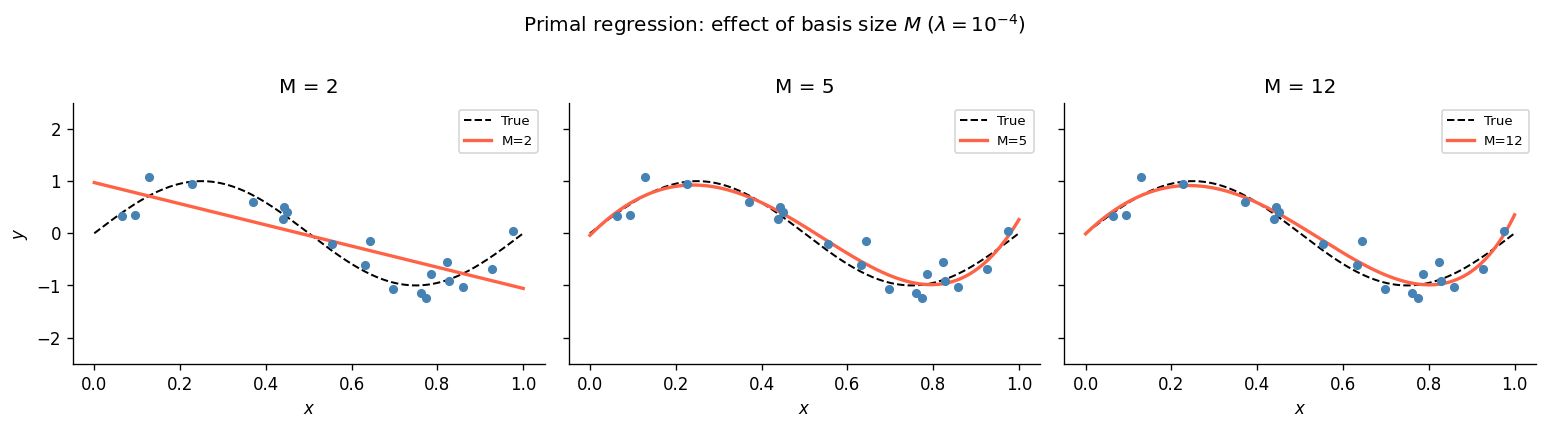

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
lam = 1e-4

for ax, M in zip(axes, [2, 5, 12]):
    Phi = design_matrix(X_train, M)
    w_hat = primal_fit(Phi, y_train, lam)
    y_pred = primal_predict(w_hat, X_plot, M)

    ax.plot(X_plot, true_function(X_plot), 'k--', lw=1.2, label='True')
    ax.scatter(X_train, y_train, color='steelblue', s=20, zorder=3)
    ax.plot(X_plot, y_pred, color='tomato', lw=2, label=f'M={M}')
    ax.set_title(f'M = {M}')
    ax.set_xlabel('$x$'); ax.set_ylim(-2.5, 2.5)
    ax.legend(fontsize=8)

axes[0].set_ylabel('$y$')
fig.suptitle(r'Primal regression: effect of basis size $M$ ($\lambda=10^{-4}$)', y=1.01)
plt.tight_layout(); plt.show()

---
## 3. Dual Formulation and the Kernel Trick

### Representer theorem

The optimal weight vector $\hat{w}$ lies in the span of the training feature vectors:

$$w = \sum_{j=1}^N a_j \phi(x_j) = \Phi^T a, \qquad a \in \mathbb{R}^N.$$

The variables $a$ are called **dual variables**.

### Gram matrix

Define the **kernel** $k(x_i, x_j) = \phi(x_i)^T \phi(x_j)$ and the **Gram matrix**

$$K \in \mathbb{R}^{N \times N}, \qquad K_{ij} = k(x_i, x_j).$$

It follows that $w^T\phi(x_i) = a^T K^i$ where $K^i$ denotes the $i$-th column.

### Dual objective

Substituting $w = \Phi^T a$ into $E(w)$:

$$E(a) = \sum_{n=1}^N (y_n - a^T K^n)^2 + \lambda\, a^T K a = \|\mathbf{y} - Ka\|^2 + \lambda\, a^T K a.$$

Setting $\nabla_a E = 0$:

$$\hat{a} = (K + \lambda I)^{-1}\mathbf{y}$$

### Prediction (kernel trick)

For a new point $x^\text{new}$, let $K_\text{new} = (k(x^\text{new}, x_1), \ldots, k(x^\text{new}, x_N))^T \in \mathbb{R}^N$. Then:

$$y(x^\text{new}) = K_\text{new}^T (K + \lambda I)^{-1}\mathbf{y}.$$

We never need $\phi$ explicitly, only pairwise kernel evaluations. This unlocks infinite-dimensional feature spaces at $\mathcal{O}(N^3)$ cost, independent of $M$.

In [25]:
def gram_matrix(X1, X2, kernel_fn, **kwargs):
    """Compute Gram matrix K[i,j] = k(X1[i], X2[j])."""
    return np.array([[kernel_fn(x1, x2, **kwargs) for x2 in X2] for x1 in X1])

def dual_fit(K, y, lam):
    """a_hat = (K + lam*I)^{-1} y."""
    N = K.shape[0]
    return np.linalg.solve(K + lam * np.eye(N), y)

def dual_predict(a_hat, K_star):
    """y* = K_star^T a_hat.  K_star shape: (N, n_test)."""
    return K_star.T @ a_hat

def poly_kernel(x1, x2, M=5):
    """k(x1,x2) = phi(x1)^T phi(x2) for polynomial map of degree M-1."""
    return sum(x1**m * x2**m for m in range(M))

Max absolute difference (primal vs dual): 7.99e-12


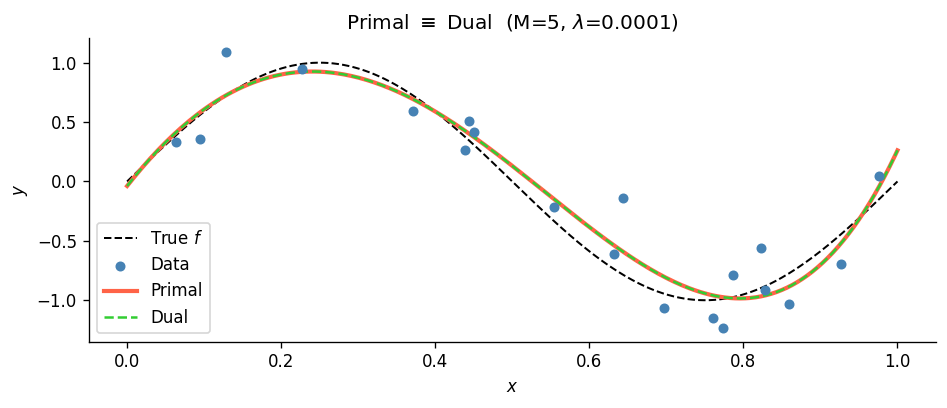

In [26]:
M = 5
lam = 1e-4

# Primal
Phi = design_matrix(X_train, M)
w_hat = primal_fit(Phi, y_train, lam)
y_primal = primal_predict(w_hat, X_plot, M)

# Dual
K = gram_matrix(X_train, X_train, poly_kernel, M=M)
a_hat = dual_fit(K, y_train, lam)
K_star = gram_matrix(X_train, X_plot, poly_kernel, M=M)  # (N, n_test)
y_dual = dual_predict(a_hat, K_star)

print(f'Max absolute difference (primal vs dual): {np.max(np.abs(y_primal - y_dual)):.2e}')

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(X_plot, true_function(X_plot), 'k--', lw=1.2, label='True $f$')
ax.scatter(X_train, y_train, color='steelblue', s=25, zorder=4, label='Data')
ax.plot(X_plot, y_primal, color='tomato', lw=2.5, label='Primal')
ax.plot(X_plot, y_dual, color='limegreen', lw=1.5, ls='--', label='Dual')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title(f'Primal $\\equiv$ Dual  (M={M}, $\\lambda$={lam})')
ax.legend(); plt.tight_layout(); plt.show()

---
## 4. Kernel Functions

A function $k : \mathcal{X} \times \mathcal{X} \to \mathbb{R}$ is a **valid kernel** if and only if the Gram matrix $K$ is **positive semi-definite** for any finite set of points.


### RBF / Gaussian kernel

$$k_{\text{RBF}}(x, x') = \alpha \exp\!\left(-\frac{(x-x')^2}{\ell^2}\right)$$

$\alpha$ = amplitude, $\ell$ = length-scale. Corresponds to an **infinite-dimensional** feature space; the GP it induces is infinitely differentiable.

### Matérn 1/2 kernel (Exponential)

$$k_{\text{Mat}_{1/2}}(r) = \exp\!\left(-\frac{r}{\ell}\right), \qquad r = |x - x'|.$$

Continuous but nowhere differentiable sample paths.


### Periodic kernel

$$k_{\text{Per}}(x, x') = \exp\!\left(-\frac{2\sin^2\!\left(\frac{x-x'}{2}\right)}{\ell^2}\right).$$

### Polynomial kernel

$$k_{\text{Poly}}(x, x') = (x\, x')^p.$$

Corresponds exactly to monomials of degree $p$.

In [27]:
def rbf_kernel(x1, x2, amplitude=1.0, length_scale=1.0):
    return amplitude * np.exp(-((x1 - x2)**2) / length_scale**2)

def matern12_kernel(x1, x2, length_scale=1.0):
    r = abs(x1 - x2)
    return np.exp(-r / length_scale)

def periodic_kernel(x1, x2, length_scale=1.0, period=1.0):
    return np.exp(-2 * np.sin(np.pi * abs(x1 - x2) / period)**2 / length_scale**2)

def poly_kernel_p(x1, x2, p=2):
    return (x1 * x2)**p

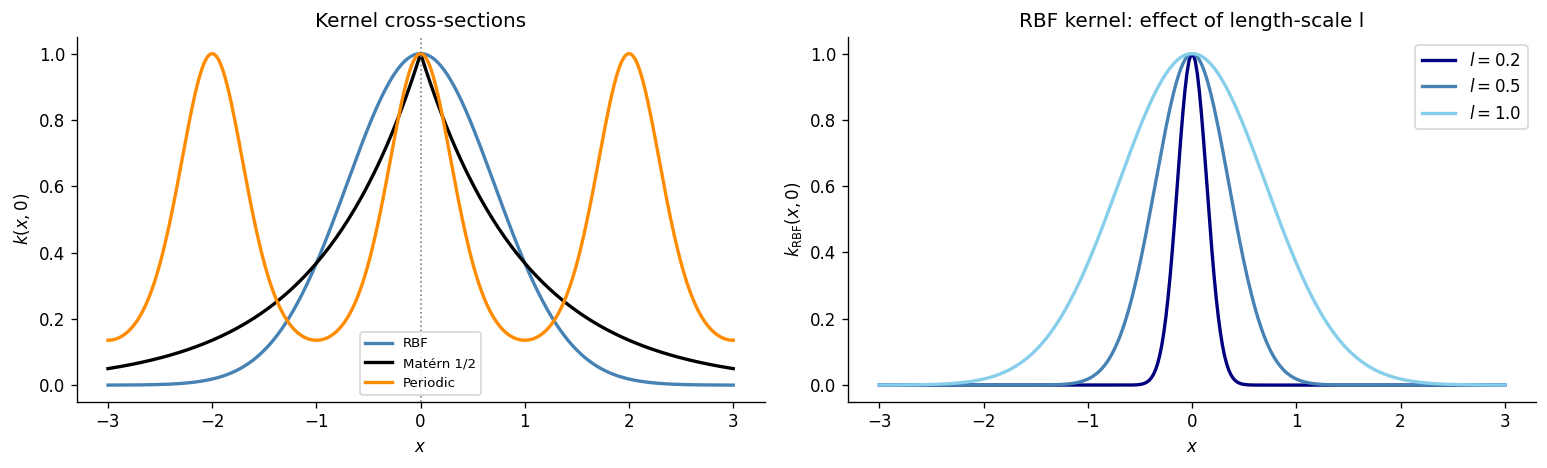

In [28]:
x_ref = 0.0
x_grid = np.linspace(-3, 3, 300)

kernels = [
    ('RBF', rbf_kernel, dict(amplitude=1.0, length_scale=1.0), 'steelblue'),
    ('Matérn 1/2', matern12_kernel, dict(length_scale=1.0), 'black'),
    ('Periodic', periodic_kernel, dict(length_scale=1.0, period=2.0), 'darkorange'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: k(x, 0) cross-sections
ax = axes[0]
for name, kfn, kw, col in kernels:
    vals = np.array([kfn(x, x_ref, **kw) for x in x_grid])
    ax.plot(x_grid, vals, color=col, lw=2, label=name)
ax.axvline(x_ref, color='gray', ls=':', lw=1)
ax.set_xlabel('$x$'); ax.set_ylabel(r'$k(x, 0)$')
ax.set_title('Kernel cross-sections')
ax.legend(fontsize=8)

# Right: Effect of length-scale on RBF
ax = axes[1]
for ls, col in [(0.2, 'navy'), (0.5, 'steelblue'), (1.0, 'skyblue')]:
    vals = np.array([rbf_kernel(x, x_ref, length_scale=ls) for x in x_grid])
    ax.plot(x_grid, vals, color=col, lw=2, label=fr'$l={ls}$')
ax.set_xlabel('$x$'); ax.set_ylabel(r'$k_{\mathrm{RBF}}(x, 0)$')
ax.set_title('RBF kernel: effect of length-scale l')
ax.legend()

plt.tight_layout(); plt.show()

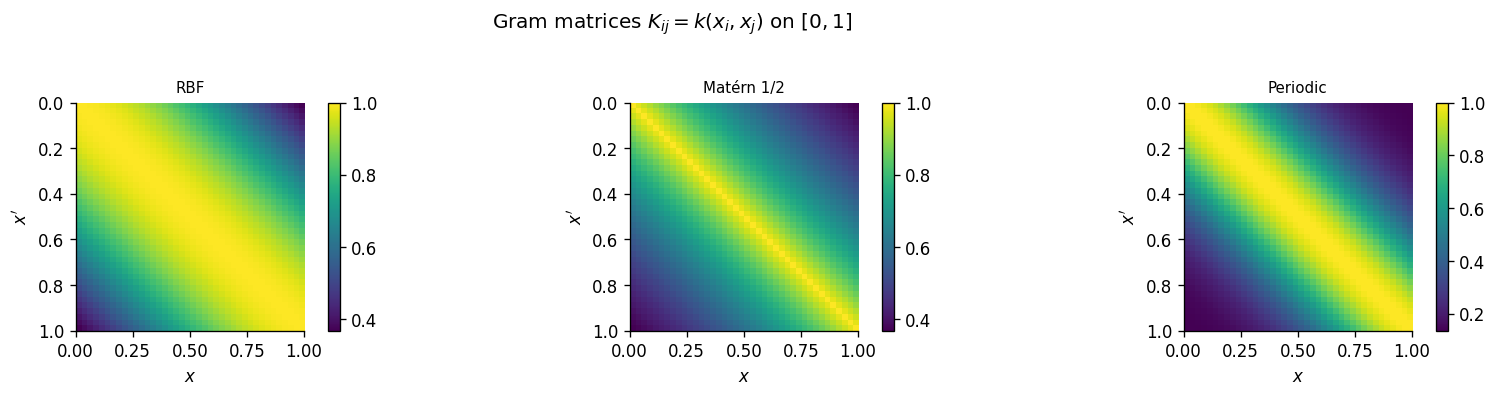

In [29]:
x_heat = np.linspace(0, 1, 40)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
for ax, (name, kfn, kw, _) in zip(axes, kernels):
    K = gram_matrix(x_heat, x_heat, kfn, **kw)
    im = ax.imshow(K, cmap='viridis', origin='upper', extent=[0, 1, 1, 0])
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('$x$'); ax.set_ylabel("$x'$")
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle('Gram matrices $K_{ij} = k(x_i, x_j)$ on $[0,1]$', y=1.02)
plt.tight_layout(); plt.show()

---
## 5. Random Functions and the GP Prior

### Distribution over functions

A **Gaussian Process** is a distribution over functions. Formally:

> *A GP is a stochastic process indexed by $x \in \mathbb{R}^n$ such that every finite collection of function values $(f(x_1), \ldots, f(x_N))$ is jointly Gaussian.*

We write $f \sim \mathcal{GP}(\mu, k)$, where:
- $\mu : \mathbb{R}^n \to \mathbb{R}$ is the **mean function**, $\mu(x) = \mathbb{E}[f(x)]$;
- $k : \mathbb{R}^n \times \mathbb{R}^n \to \mathbb{R}$ is the **covariance function**.

For any finite set $x_1, \ldots, x_N$:

$$p(f(x_1), \ldots, f(x_N)) = \mathcal{N}(\boldsymbol{\mu},\, K), \qquad K_{ij} = k(x_i, x_j).$$

### Sampling from the prior

To draw a sample function on a grid $X$:
1. Build $K = k(X, X)$ and add a small jitter $\varepsilon I$ for numerical stability.
2. Compute the Cholesky factor $K + \varepsilon I = L L^T$.
3. Sample $\mathbf{z} \sim \mathcal{N}(0, I)$ and return $\mathbf{f} = \mu + L\mathbf{z}$.

The pointwise **prior variance** is $\sigma^2(x) = k(x, x)$, giving the $\pm 2\sigma$ band.

In [30]:
JITTER = 1e-8

def sample_gp_prior(X, kernel_fn, n_samples=5, mean_fn=None, **kwargs):
    """Draw n_samples functions from GP(mean_fn, kernel_fn) on grid X."""
    N = len(X)
    K = gram_matrix(X, X, kernel_fn, **kwargs) + JITTER * np.eye(N)
    L = np.linalg.cholesky(K)           # K = L L^T
    z = rng.standard_normal((N, n_samples))
    mu = mean_fn(X) if mean_fn else np.zeros(N)
    return mu[:, None] + L @ z           # (N, n_samples)

def prior_std(X, kernel_fn, **kwargs):
    """Pointwise prior std: sqrt(k(x, x))."""
    return np.sqrt(np.array([kernel_fn(x, x, **kwargs) for x in X]))

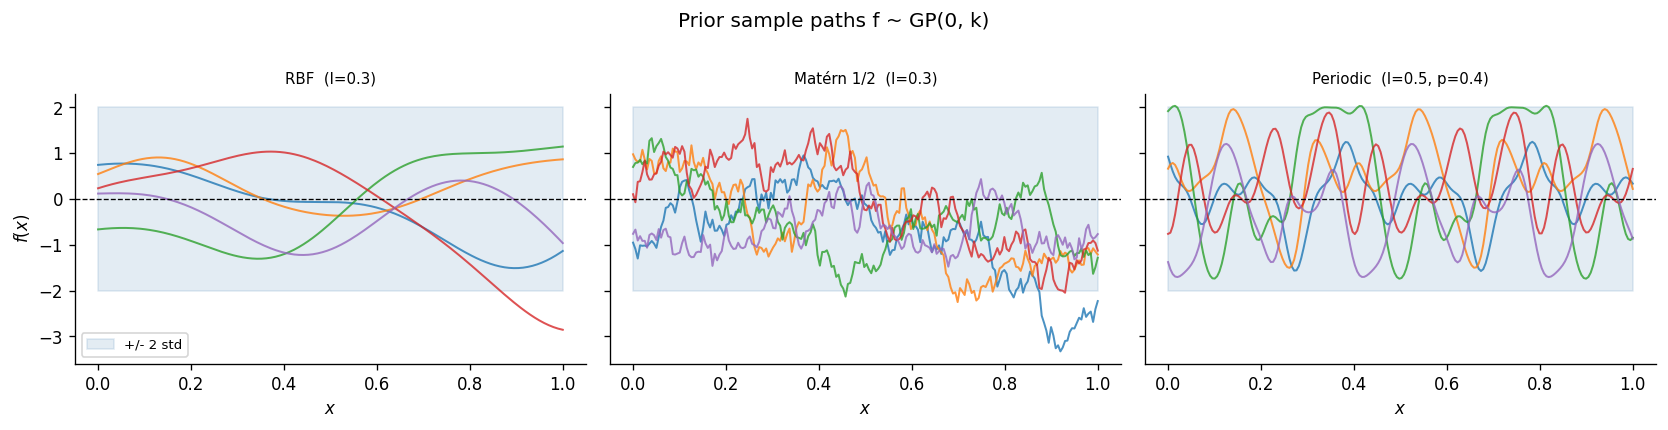

In [31]:
prior_kernels = [
    ('RBF  (l=0.3)', rbf_kernel, dict(amplitude=1.0, length_scale=0.3)),
    ('Matérn 1/2  (l=0.3)', matern12_kernel, dict(length_scale=0.3)),
    ('Periodic  (l=0.5, p=0.4)', periodic_kernel, dict(length_scale=0.5, period=0.4)),
]

X_prior = np.linspace(0, 1, 200)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
for ax, (title, kfn, kw) in zip(axes, prior_kernels):
    samples = sample_gp_prior(X_prior, kfn, n_samples=5, **kw)
    std = prior_std(X_prior, kfn, **kw)
    ax.fill_between(X_prior, -2*std, 2*std, alpha=0.15, color='steelblue', label='+/- 2 std')
    for s in range(samples.shape[1]):
        ax.plot(X_prior, samples[:, s], lw=1.2, alpha=0.8)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('$x$')

axes[0].set_ylabel('$f(x)$')
axes[0].legend(fontsize=8)
fig.suptitle('Prior sample paths f ~ GP(0, k)', y=1.01)
plt.tight_layout(); plt.show()

---
## 6. GP Regression: Noise-free Case

Assume we **observe exactly** $\mathbf{f} = (f(x_1), \ldots, f(x_N))^T$ at training inputs $\mathbf{x} = (x_1, \ldots, x_N)$.

Place a GP prior $f \sim \mathcal{GP}(0, k)$. The **joint** distribution of training values $\mathbf{f}$ and test values $\mathbf{f}^* = (f(x_1^*), \ldots, f(x_T^*))^T$ is:

$$p\!\begin{pmatrix}\mathbf{f}\\ \mathbf{f}^*\end{pmatrix} \sim \mathcal{N}\!\left(\mathbf{0},\, \begin{bmatrix}K(\mathbf{x},\mathbf{x}) & K(\mathbf{x},\mathbf{x}^*)\\ K(\mathbf{x}^*,\mathbf{x}) & K(\mathbf{x}^*,\mathbf{x}^*)\end{bmatrix}\right).$$

Using the **Gaussian conditioning formula**, the posterior is:

$$p(\mathbf{f}^*\mid\mathbf{f}) \sim \mathcal{N}(\boldsymbol{\mu}_{\text{post}},\, \Sigma_{\text{post}}),$$

$$\boldsymbol{\mu}_{\text{post}} = K(\mathbf{x}^*,\mathbf{x})\, K(\mathbf{x},\mathbf{x})^{-1}\, \mathbf{f},$$

$$\Sigma_{\text{post}} = K(\mathbf{x}^*,\mathbf{x}^*) - K(\mathbf{x}^*,\mathbf{x})\, K(\mathbf{x},\mathbf{x})^{-1}\, K(\mathbf{x},\mathbf{x}^*).$$



In [32]:
def gp_posterior_noisefree(X_train, f_train, X_test, kernel_fn, **kwargs):
    """
    Returns posterior mean (n_test,) and std (n_test,) for noise-free GP.
    """
    N = len(X_train)
    K_tt = gram_matrix(X_train, X_train, kernel_fn, **kwargs) + JITTER * np.eye(N)
    K_ts = gram_matrix(X_train, X_test,  kernel_fn, **kwargs)  # (N, n_test)
    K_ss = gram_matrix(X_test,  X_test,  kernel_fn, **kwargs)  # (n_test, n_test)

    # Solve K_tt v = f_train  and  K_tt V = K_ts  via Cholesky
    c, low = cho_factor(K_tt)
    alpha  = cho_solve((c, low), f_train)   # K_tt^{-1} f
    V      = cho_solve((c, low), K_ts)      # K_tt^{-1} K_ts

    mu_post    = K_ts.T @ alpha
    Sigma_post = K_ss - K_ts.T @ V
    std_post   = np.sqrt(np.maximum(np.diag(Sigma_post), 0))
    return mu_post, std_post, Sigma_post

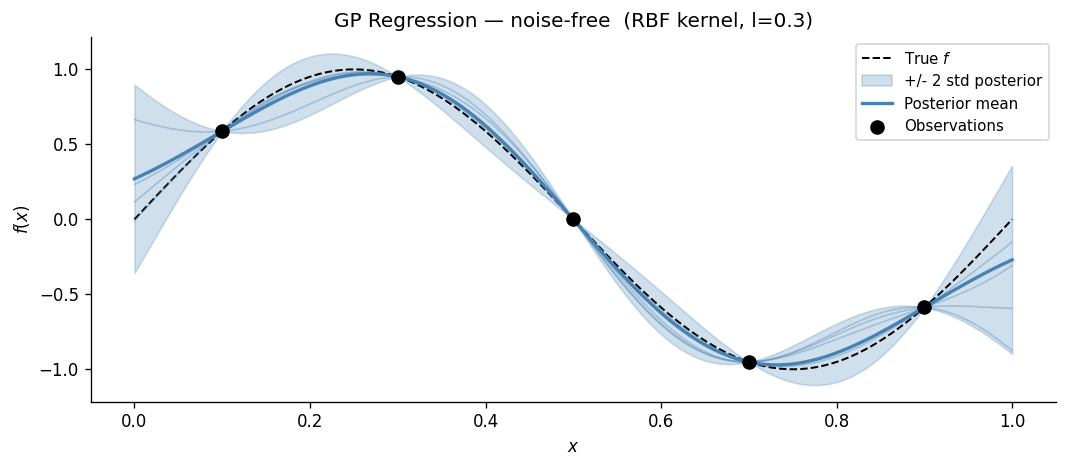

In [33]:
# Use a small noise-free dataset (exact observations)
X_nf = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
f_nf = true_function(X_nf)

mu_nf, std_nf, Sigma_nf = gp_posterior_noisefree(
    X_nf, f_nf, X_plot, rbf_kernel, amplitude=1.0, length_scale=0.3)

# Draw posterior samples
L_post = np.linalg.cholesky(Sigma_nf + JITTER * np.eye(len(X_plot)))
post_samples = mu_nf[:, None] + L_post @ rng.standard_normal((len(X_plot), 4))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(X_plot, true_function(X_plot), 'k--', lw=1.2, label='True $f$')
ax.fill_between(X_plot, mu_nf - 2*std_nf, mu_nf + 2*std_nf,
                alpha=0.25, color='steelblue', label='+/- 2 std posterior')
ax.plot(X_plot, mu_nf, color='steelblue', lw=2, label='Posterior mean')
for s in range(post_samples.shape[1]):
    ax.plot(X_plot, post_samples[:, s], color='steelblue', alpha=0.35, lw=1)
ax.scatter(X_nf, f_nf, color='black', zorder=5, s=60, label='Observations')
ax.set_xlabel('$x$'); ax.set_ylabel('$f(x)$')
ax.set_title('GP Regression — noise-free  (RBF kernel, l=0.3)')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

---
## 7. GP Regression: Noisy Setting

### Observation model

We now observe **noisy** values:

$$y(x) = f(x) + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, \sigma^2).$$

Because observations are i.i.d. given $f$, the observation covariance becomes:

$$\mathrm{Cov}(\mathbf{y}) = K(\mathbf{x},\mathbf{x}) + \sigma^2 I.$$

### Noisy posterior

The joint distribution over observations and test function values is:

$$p\!\begin{pmatrix}\mathbf{y}\\ \mathbf{f}^*\end{pmatrix} \sim \mathcal{N}\!\left(\mathbf{0},\, \begin{bmatrix}K(\mathbf{x},\mathbf{x}) + \sigma^2 I & K(\mathbf{x},\mathbf{x}^*)\\ K(\mathbf{x}^*,\mathbf{x}) & K(\mathbf{x}^*,\mathbf{x}^*)\end{bmatrix}\right).$$

Conditioning on $\mathbf{y}$:

$$p(\mathbf{f}^*\mid\mathbf{y}) \sim \mathcal{N}(\boldsymbol{\mu}_{\text{post}},\, \Sigma_{\text{post}}),$$

$$\boldsymbol{\mu}_{\text{post}} = K(\mathbf{x}^*,\mathbf{x})\,[K(\mathbf{x},\mathbf{x}) + \sigma^2 I]^{-1}\,\mathbf{y},$$

$$\Sigma_{\text{post}} = K(\mathbf{x}^*,\mathbf{x}^*) - K(\mathbf{x}^*,\mathbf{x})\,[K(\mathbf{x},\mathbf{x}) + \sigma^2 I]^{-1}\,K(\mathbf{x},\mathbf{x}^*).$$

The dominant cost is the $N \times N$ linear solve, i.e. $\mathcal{O}(N^3)$.

**Connection to dual regression:** the posterior mean can be written as

$$\mathbb{E}[f(x^*)\mid\mathbf{y}] = \sum_{i=1}^N \alpha_i\, k(x^*, x_i), \qquad \boldsymbol{\alpha} = [K + \sigma^2 I]^{-1}\mathbf{y},$$

which is exactly the dual regression predictor with $\lambda = \sigma^2$.

In [34]:
def gp_posterior(X_train, y_train, X_test, kernel_fn, noise_var, **kwargs):
    """
    GP regression posterior for noisy observations.
    Returns posterior mean (n_test,), std (n_test,), full cov (n_test, n_test).
    """
    N = len(X_train)
    K_tt = gram_matrix(X_train, X_train, kernel_fn, **kwargs)
    K_ts = gram_matrix(X_train, X_test,  kernel_fn, **kwargs)  # (N, n_test)
    K_ss = gram_matrix(X_test,  X_test,  kernel_fn, **kwargs)

    K_noisy = K_tt + noise_var * np.eye(N) + JITTER * np.eye(N)
    c, low  = cho_factor(K_noisy)
    alpha   = cho_solve((c, low), y_train)   # alphas
    V       = cho_solve((c, low), K_ts)      # (N, n_test)

    mu_post    = K_ts.T @ alpha
    Sigma_post = K_ss - K_ts.T @ V
    std_post   = np.sqrt(np.maximum(np.diag(Sigma_post), 0))
    return mu_post, std_post, Sigma_post

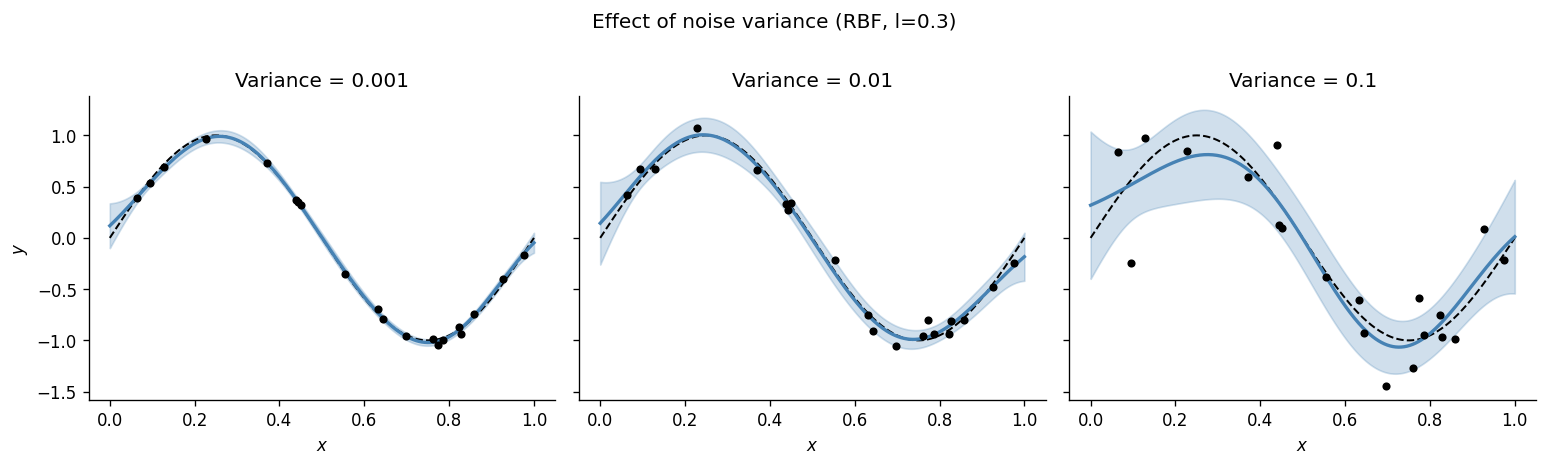

In [35]:
# Effect of noise variance
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
kw = dict(amplitude=1.0, length_scale=0.3)

for ax, nv in zip(axes, [1e-3, 0.01, 0.1]):
    y_train = true_function(X_train) + rng.normal(0, np.sqrt(nv), len(X_train))
    mu, std, _ = gp_posterior(X_train, y_train, X_plot, rbf_kernel, noise_var=nv, **kw)
    ax.plot(X_plot, true_function(X_plot), 'k--', lw=1.2)
    ax.fill_between(X_plot, mu - 2*std, mu + 2*std, alpha=0.25, color='steelblue')
    ax.plot(X_plot, mu, color='steelblue', lw=2)
    ax.scatter(X_train, y_train, color='black', s=15, zorder=4)
    ax.set_title(fr'Variance = {nv}')
    ax.set_xlabel('$x$')

axes[0].set_ylabel('$y$')
fig.suptitle('Effect of noise variance (RBF, l=0.3)', y=1.01)
plt.tight_layout()
plt.show()

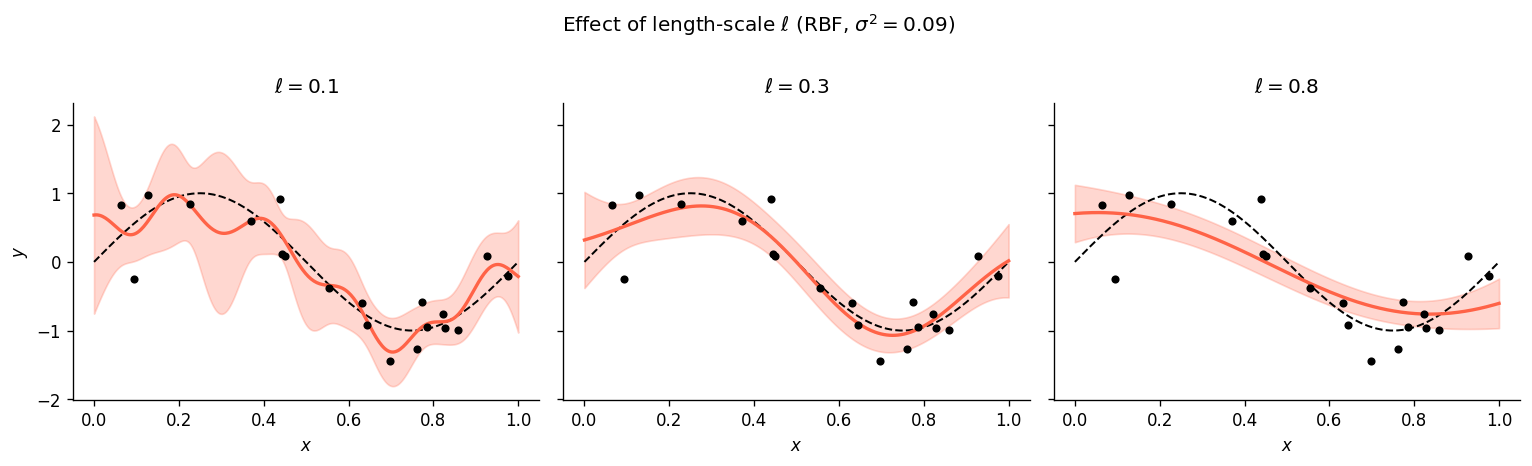

In [36]:
# Effect of length-scale
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
nv = sigma_obs**2

for ax, ls in zip(axes, [0.1, 0.3, 0.8]):
    mu, std, _ = gp_posterior(X_train, y_train, X_plot, rbf_kernel,
                               noise_var=nv, amplitude=1.0, length_scale=ls)
    ax.plot(X_plot, true_function(X_plot), 'k--', lw=1.2)
    ax.fill_between(X_plot, mu - 2*std, mu + 2*std, alpha=0.25, color='tomato')
    ax.plot(X_plot, mu, color='tomato', lw=2)
    ax.scatter(X_train, y_train, color='black', s=15, zorder=4)
    ax.set_title(fr'$\ell = {ls}$')
    ax.set_xlabel('$x$')

axes[0].set_ylabel('$y$')
fig.suptitle(r'Effect of length-scale $\ell$ (RBF, $\sigma^2=0.09$)', y=1.01)
plt.tight_layout(); plt.show()

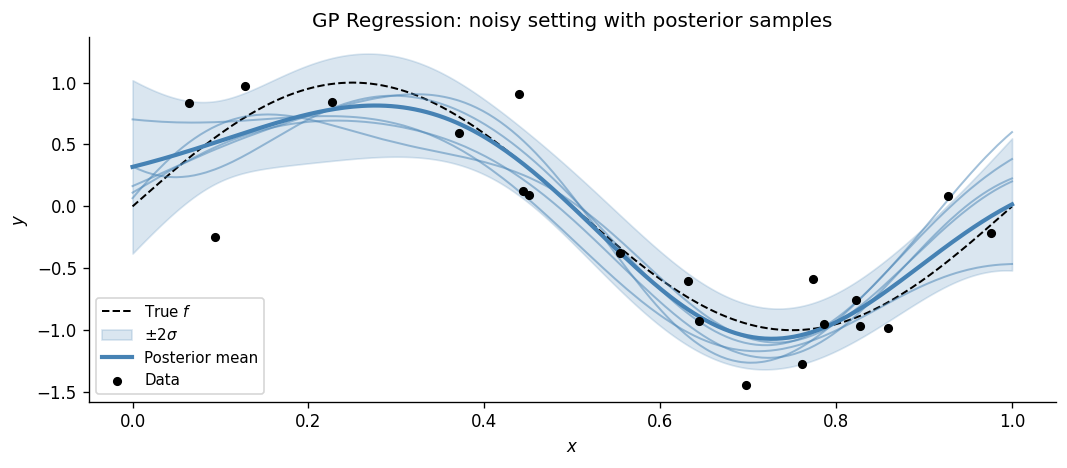

In [37]:
# Posterior sample paths
mu, std, Sigma = gp_posterior(X_train, y_train, X_plot, rbf_kernel,
                               noise_var=sigma_obs**2, amplitude=1.0, length_scale=0.3)
L_post = np.linalg.cholesky(Sigma + JITTER * np.eye(len(X_plot)))
post_samples = mu[:, None] + L_post @ rng.standard_normal((len(X_plot), 5))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(X_plot, true_function(X_plot), 'k--', lw=1.2, label='True $f$')
ax.fill_between(X_plot, mu - 2*std, mu + 2*std,
                alpha=0.2, color='steelblue', label='$\\pm 2\\sigma$')
ax.plot(X_plot, mu, color='steelblue', lw=2.5, label='Posterior mean')
for s in range(post_samples.shape[1]):
    ax.plot(X_plot, post_samples[:, s], alpha=0.5, lw=1.2, color='steelblue')
ax.scatter(X_train, y_train, color='black', s=20, zorder=5, label='Data')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('GP Regression: noisy setting with posterior samples')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

---
## 8. Hyperparameter Optimisation via Log Marginal Likelihood

The kernel hyperparameters (e.g. $\ell$, $\sigma^2$) are typically unknown. We fit them by maximising the **log marginal likelihood** (LML):

$$\mathcal{L}(\theta) = \log p(\mathbf{y}\mid\mathbf{x},\theta) = \log \int p(\mathbf{y}\mid\mathbf{f}) \, p(\mathbf{f}\mid\mathbf{x},\theta)\, d\mathbf{f}.$$

Since $\mathbf{y} \sim \mathcal{N}(0, K + \sigma^2 I)$ this integral is tractable and gives:

$$\mathcal{L}(\theta) = -\frac{1}{2}\mathbf{y}^T (K + \sigma^2 I)^{-1}\mathbf{y} - \frac{1}{2}\log |K + \sigma^2 I| - \frac{N}{2}\log 2\pi.$$

The three terms balance:
- $-\tfrac{1}{2}\mathbf{y}^T(K+\sigma^2 I)^{-1}\mathbf{y}$ — **data fit**;
- $-\tfrac{1}{2}\log |K + \sigma^2 I|$ — **complexity penalty** (Occam's razor);
- $-\tfrac{N}{2}\log 2\pi$ — constant.

We perform a 2-D grid search over $(\ell, \sigma^2)$ to visualise the LML landscape.

In [38]:
def log_marginal_likelihood(X_train, y_train, kernel_fn, noise_var, **kwargs):
    """Compute log p(y | X, theta)."""
    N = len(X_train)
    K = gram_matrix(X_train, X_train, kernel_fn, **kwargs)
    K_noisy = K + noise_var * np.eye(N) + JITTER * np.eye(N)
    try:
        c, low = cho_factor(K_noisy)
    except np.linalg.LinAlgError:
        return -np.inf
    alpha   = cho_solve((c, low), y_train)
    log_det = 2 * np.sum(np.log(np.diag(c if not low else c.T)))
    return -0.5 * (y_train @ alpha + log_det + N * np.log(2 * np.pi))

Best length-scale: 0.342   Best noise variance: 0.131
True sigma^2 = 0.090


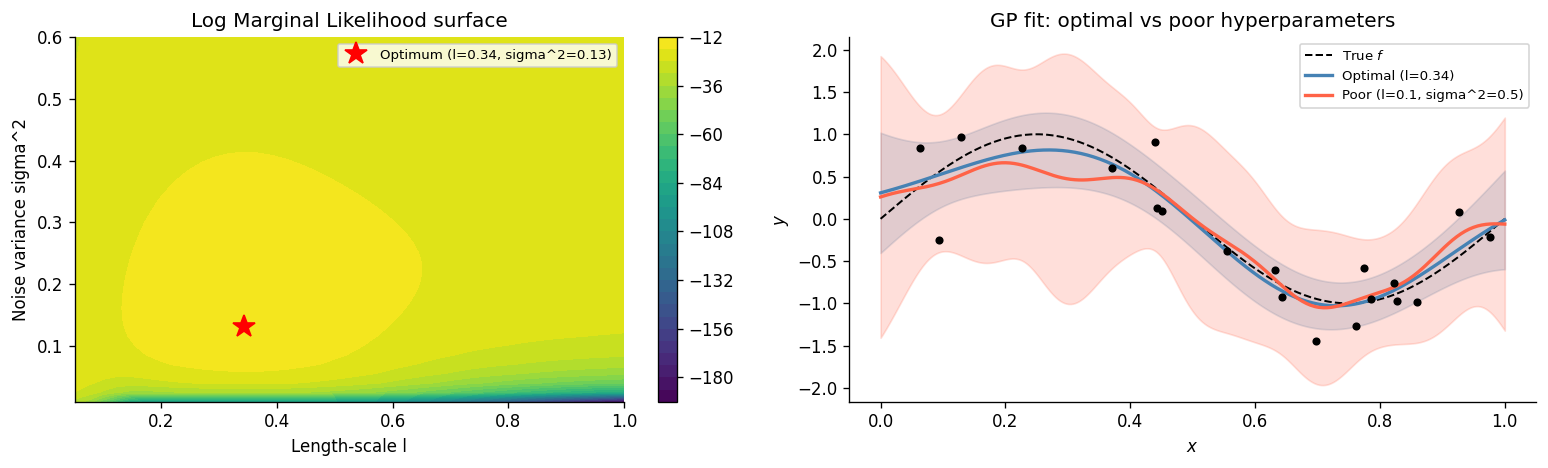

In [39]:
ls_grid  = np.linspace(0.05, 1.0, 40)
nv_grid  = np.linspace(0.01, 0.6, 40)

LML = np.zeros((len(nv_grid), len(ls_grid)))
for i, nv in enumerate(nv_grid):
    for j, ls in enumerate(ls_grid):
        LML[i, j] = log_marginal_likelihood(
            X_train, y_train, rbf_kernel, nv, amplitude=1.0, length_scale=ls)

best_idx = np.unravel_index(np.argmax(LML), LML.shape)
best_ls  = ls_grid[best_idx[1]]
best_nv  = nv_grid[best_idx[0]]
print(f'Best length-scale: {best_ls:.3f}   Best noise variance: {best_nv:.3f}')
print(f'True sigma^2 = {sigma_obs**2:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
im = ax.contourf(ls_grid, nv_grid, LML, levels=30, cmap='viridis')
ax.plot(best_ls, best_nv, 'r*', ms=14, label=f'Optimum (l={best_ls:.2f}, sigma^2={best_nv:.2f})')
ax.set_xlabel(r'Length-scale l')
ax.set_ylabel(r'Noise variance sigma^2')
ax.set_title('Log Marginal Likelihood surface')
ax.legend(fontsize=8)
plt.colorbar(im, ax=ax)

# Compare GP fit at optimal vs arbitrary hyperparameters
ax = axes[1]
ax.plot(X_plot, true_function(X_plot), 'k--', lw=1.2, label='True $f$')
ax.scatter(X_train, y_train, color='black', s=15, zorder=5)

for (ls, nv, col, lbl) in [
    (best_ls, best_nv, 'steelblue', f'Optimal (l={best_ls:.2f})'),
    (0.1,     0.5,     'tomato',    'Poor (l=0.1, sigma^2=0.5)'),
]:
    mu, std, _ = gp_posterior(X_train, y_train, X_plot, rbf_kernel,
                               noise_var=nv, amplitude=1.0, length_scale=ls)
    ax.fill_between(X_plot, mu - 2*std, mu + 2*std, alpha=0.2, color=col)
    ax.plot(X_plot, mu, color=col, lw=2, label=lbl)

ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('GP fit: optimal vs poor hyperparameters')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Forecasting of CO2 level on Mona Loa dataset using Gaussian process regression (GPR)

## Data

In [40]:
from sklearn.datasets import fetch_openml

In [41]:
co2 = fetch_openml(data_id=41187, as_frame=True)
co2.frame.head()

,year,month,day,weight,flag,station,co2
0,1958,3,29,4,0,MLO,316.1
1,1958,4,5,6,0,MLO,317.3
2,1958,4,12,4,0,MLO,317.6
3,1958,4,19,6,0,MLO,317.5
4,1958,4,26,2,0,MLO,316.4


## Design the kernel

## Fit

## Predict